In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split  
from imutils import paths
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
import numpy as np
import shutil
import os

In [2]:
ORIG_INPUT_DATASET = "House_Room_Dataset/Bedroom"

TRAIN = "training"
VAL = "evaluation"
TEST = "testing"

BASE_PATH = "dataset"
BATCH_SIZE = 32
CLASS_NAMES = ["Modern", "Old"]

In [3]:
def plot_hist(hist,metric):
    if metric == "auc":
        plt.plot(hist.history['auc'])
        plt.plot(hist.history['val_auc'])

    else:
        plt.plot(hist.history['loss'])
        plt.plot(hist.history['val_loss'])   

    plt.style.use("ggplot")
    plt.title("model {}".format(metric)) 
    plt.ylabel("{}".format(metric))    
    plt.xlabel("epoch") 
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()

In [4]:
# Reading labels from the txt file
with open("labels.txt", 'r') as f:
      manual_labels = f.read()
# Extracting individual labels into a list
labels = [i for i in manual_labels]
len(labels)

451

In [5]:
from collections import Counter
print(Counter(labels).keys())
print(Counter(labels).values())

dict_keys(['O', 'M'])
dict_values([271, 180])


In [6]:
# sorting files in the order they appear
import os
files = os.listdir(ORIG_INPUT_DATASET)
files.sort(key=lambda f: int(f.split("_")[1].split(".")[0]))

#checking to see the correct file order
files[:5]

['bed_1.jpg', 'bed_2.jpg', 'bed_3.jpg', 'bed_4.jpg', 'bed_8.jpg']

In [7]:
# splitting files into train and test sets
trainX, testX, trainY, testY =  train_test_split(files[:len(labels)], 
                 labels, 
                 stratify=labels, 
                 train_size=0.90)
# further splitting of train set into train and val sets
trainX, valX, trainY, valY = train_test_split(trainX, trainY, stratify=trainY, train_size=0.85)
# Checking the size of train, test, eval
len(trainX), len(trainY), len(valX), len(valY),  len(testX), len(testY)

(344, 344, 61, 61, 46, 46)

In [8]:
# Building the dataset properly - 

splits = [(trainX, trainY), (testX, testY), (valX, valY)]
dirnames = ['training', 'testing', 'validation']
for i, (data, label) in enumerate(splits):
    outside_dir = dirnames[i]

    for j in tqdm(range(len(label)), desc="Iterating over images in sub folder"):
        class_name = label[j]

        dirPath = os.path.join(BASE_PATH, outside_dir, class_name)

        if not os.path.exists(dirPath):
            os.makedirs(dirPath)

        src_img = os.path.join(ORIG_INPUT_DATASET, data[j])

        shutil.copy(src_img, dirPath)

Iterating over images in sub folder: 100%|██████████| 61/61 [00:00<00:00, 98.39it/s] 


In [9]:
BASE_PATH = "dataset"

TRAIN = "training"
TEST = "testing"
VAL = "validation"

trainPath = os.path.join(BASE_PATH, TRAIN)
valPath = os.path.join(BASE_PATH, VAL)
testPath = os.path.join(BASE_PATH, TEST)

totalTrain = len(list(paths.list_images(trainPath)))
totalVal = len(list(paths.list_images(valPath)))
totalTest = len(list(paths.list_images(testPath)))

print(totalTrain, totalTest, totalVal)

413 82 108


In [10]:
trainAug = ImageDataGenerator(
rotation_range=90,
zoom_range=[0.5, 1.0],
width_shift_range=0.3,
height_shift_range=0.25,
shear_range=0.15,
horizontal_flip=True,
fill_mode="nearest",
brightness_range=[0.2, 1.0]
)

In [11]:
valAug = ImageDataGenerator()
testAug = ImageDataGenerator()

In [12]:
# Create training batches whilst creating augmented images on the fly
trainGen = trainAug.flow_from_directory(
directory=trainPath,
target_size=(224,224),
save_to_dir='dataset/augmented/train',
save_prefix='train',
shuffle=True
)
# Create val batches 
valGen = valAug.flow_from_directory(
directory=valPath,
target_size=(224,224),
shuffle=True
)

Found 413 images belonging to 2 classes.
Found 108 images belonging to 2 classes.


In [13]:
import os

print("TEST =", TEST)
print("testPath =", testPath)
print("Exists?", os.path.exists(testPath))
print("Dataset folders:", os.listdir(BASE_PATH))

TEST = testing
testPath = dataset\testing
Exists? True
Dataset folders: ['augmented', 'testing', 'training', 'validation']


In [14]:
print("Testing images:", len(list(paths.list_images(testPath))))

Testing images: 82


In [15]:
# Create test batches
testGen = testAug.flow_from_directory(
    directory=testPath,
    target_size=(224, 224),
    shuffle=False
)

Found 82 images belonging to 2 classes.


In [16]:
baseModel = EfficientNetB0(
            weights="imagenet",
            include_top=False, # make sure top layer is not included
            input_tensor=Input(shape=(224, 224, 3)),
            pooling="avg"
           )

In [17]:
# freeze the weights
for layer in baseModel.layers:
      layer.trainable = False
      

In [18]:
# Another way to create the classifier on top of basemodel
model = tf.keras.Sequential()
model.add(baseModel)
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(len(CLASS_NAMES), activation="softmax"))

In [19]:
# compile
opt = Adam(learning_rate=1e-3)
model.compile(optimizer=opt, 
              loss='binary_crossentropy', 
              metrics=[tf.keras.metrics.AUC()]
              )

In [20]:
# implementing early stopping
es = EarlyStopping(
     monitor='val_loss',  #metric to monitor
     mode='min',  # whether to min or max the metric monitored
     patience=10, # epochs to wait before declaring stopped training
     verbose=1  # output epoch when training was stopped
     )
# implementing model checkpoint
mc = ModelCheckpoint(
      'feature_extraction.keras',
       monitor='val_loss',
       mode='min',
       verbose=1, # display epoch+accuracy everytime model is saved
       save_best_only=True
      )

In [21]:
import os

os.makedirs("dataset/augmented/train", exist_ok=True)

In [22]:
# Training the model

hist = model.fit(
       x=trainGen,
       epochs=25,
       verbose=2,
       validation_data=valGen,
       steps_per_epoch=totalTrain // BATCH_SIZE,
       callbacks=[es, mc]
      )

Epoch 1/25

Epoch 1: val_loss improved from None to 0.64628, saving model to feature_extraction.keras

Epoch 1: finished saving model to feature_extraction.keras
12/12 - 45s - 4s/step - auc: 0.5339 - loss: 1.0119 - val_auc: 0.7246 - val_loss: 0.6463
Epoch 2/25


e:\AIML\DL\e2eproject\E2E_Render\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.64628 to 0.64456, saving model to feature_extraction.keras

Epoch 2: finished saving model to feature_extraction.keras
12/12 - 5s - 379ms/step - auc: 0.5029 - loss: 1.1247 - val_auc: 0.7287 - val_loss: 0.6446
Epoch 3/25

Epoch 3: val_loss improved from 0.64456 to 0.62704, saving model to feature_extraction.keras

Epoch 3: finished saving model to feature_extraction.keras
12/12 - 25s - 2s/step - auc: 0.5951 - loss: 0.8906 - val_auc: 0.7407 - val_loss: 0.6270
Epoch 4/25

Epoch 4: val_loss improved from 0.62704 to 0.62563, saving model to feature_extraction.keras

Epoch 4: finished saving model to feature_extraction.keras
12/12 - 4s - 373ms/step - auc: 0.7495 - loss: 0.7216 - val_auc: 0.7401 - val_loss: 0.6256
Epoch 5/25

Epoch 5: val_loss improved from 0.62563 to 0.61691, saving model to feature_extraction.keras

Epoch 5: finished saving model to feature_extraction.keras
12/12 - 25s - 2s/step - auc: 0.6465 - loss: 0.8474 - val_auc: 0.7444 - val_loss: 0.

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  
No. of test images 82
{'M': 0, 'O': 1}


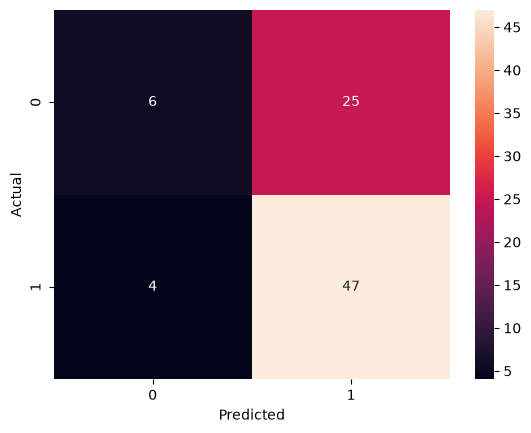

In [23]:
testGen.reset()
predIdxs = model.predict(
             x=testGen,
             steps=(totalTest // BATCH_SIZE) + 1
            )
predIdxs = np.argmax(predIdxs, axis = 1)
print("No. of test images", len(predIdxs))
print(testGen.class_indices)
cm = confusion_matrix(testGen.classes, predIdxs)
heatmap = sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
def fine_tune_model(model):
     # unfreeze last conv block i.e. block7a 
     for layer in model.layers[-20:]:
          if not isinstance(layer, BatchNormalization):
               layer.trainable = True
     # check which of these are trainable and which aren't
     for layer in model.layers:
          print("{}: {}".format(layer, layer.trainable))
     # compile (with an even smaller learning rate)
     opt = Adam(learning_rate=1e-5)
     model.compile(
             optimizer=opt,
             loss='binary_crossentropy',
             metrics=[tf.keras.metrics.AUC()]
             )
     return model
model_fine_tuned = fine_tune_model(model)

<Functional name=efficientnetb0, built=True>: True
<BatchNormalization name=batch_normalization, built=True>: True
<Dropout name=dropout, built=True>: True
<Dense name=dense, built=True>: True


In [25]:
trainGen.reset()
valGen.reset()
testGen.reset()

In [26]:
# implementing early stopping
es_tune = EarlyStopping(
     monitor='val_loss', 
     mode='min',  
     patience=20, 
     verbose=1  
     )
# implementing model checkpoint
mc_tune = ModelCheckpoint(
      'fine_tuned_house.keras',
       monitor='val_loss',
       mode='min',
       verbose=1, 
       save_best_only=True
      )
hist = model_fine_tuned.fit(
      x=trainGen,
      steps_per_epoch=totalTrain // BATCH_SIZE,
      validation_data=valGen,
      epochs=50,
      verbose=2,
      callbacks=[es_tune, mc_tune]
     )

Epoch 1/50

Epoch 1: val_loss improved from None to 0.55385, saving model to fine_tuned_house.keras

Epoch 1: finished saving model to fine_tuned_house.keras
12/12 - 35s - 3s/step - auc_1: 0.7786 - loss: 0.6454 - val_auc_1: 0.7906 - val_loss: 0.5539
Epoch 2/50


e:\AIML\DL\e2eproject\E2E_Render\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.55385 to 0.55377, saving model to fine_tuned_house.keras

Epoch 2: finished saving model to fine_tuned_house.keras
12/12 - 5s - 454ms/step - auc_1: 0.5742 - loss: 0.9775 - val_auc_1: 0.7909 - val_loss: 0.5538
Epoch 3/50

Epoch 3: val_loss improved from 0.55377 to 0.55135, saving model to fine_tuned_house.keras

Epoch 3: finished saving model to fine_tuned_house.keras
12/12 - 26s - 2s/step - auc_1: 0.8059 - loss: 0.6178 - val_auc_1: 0.7943 - val_loss: 0.5513
Epoch 4/50

Epoch 4: val_loss improved from 0.55135 to 0.55125, saving model to fine_tuned_house.keras

Epoch 4: finished saving model to fine_tuned_house.keras
12/12 - 5s - 415ms/step - auc_1: 0.6182 - loss: 0.8774 - val_auc_1: 0.7942 - val_loss: 0.5513
Epoch 5/50

Epoch 5: val_loss improved from 0.55125 to 0.54880, saving model to fine_tuned_house.keras

Epoch 5: finished saving model to fine_tuned_house.keras
12/12 - 27s - 2s/step - auc_1: 0.7555 - loss: 0.6823 - val_auc_1: 0.7939 - val_loss: 0.